# <center>Laboratorium 5<br>Metody Numeryczne</center>

Instrukcja:  
Na zajęciach należy wykonać poniższe zadania, a następnie sporządzić sprawozdanie zawierające odpowiedzi (w postaci kodu) z komentarzami w środowisku Jupyter Notebook i umieścić je na platformie e-learningowej.

***Materiały przygotowujące:***


In [4]:
import main
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
from scipy.interpolate import splev, splrep
import timeit

def PolyCoefficients(x, coeffs):
    """ Returns a polynomial for ``x`` values for the ``coeffs`` provided.
    The coefficients must be in ascending order (``x**0`` to ``x**o``).
    """
    o = len(coeffs)
    y = 0
    for i in range(o):
        y += coeffs[i]*x**i
    return y

***Zadanie 1.***  
Zaimplementuj interpolacje pierwszego stopnia. Jako dane wejściowe dane są dwa wektory: argumentów oraz wartości funkcji. Funkcja ma zwracać współczynniki funkcji liniowych w poszczególnych przedziałach.

***Podpowiedź***

poszczególne współczynniki przyjmują wartość:

$ a=\frac{y_{k+1}-y_k}{x_{k+1}-x_k}$

$ b=y-a*x_0$

***Przykład***


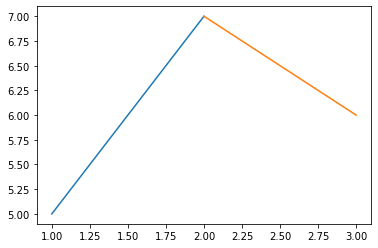

In [5]:
x=np.array([1,2,3])
y=np.array([5,7,6])

a,b=main.first_spline(x,y)
f = [[b[i],a[i]] for i in range(len(a))]

for i in range(len(x)-1):
    x_new = np.linspace(x[i], x[i+1],1000)
    plt.plot(x_new, PolyCoefficients(x_new, f[i]))

***Zadanie 2.***  
Korzystając z funkcji z pakietu [scipy.interpolate.splprep](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.splprep.html#scipy.interpolate.splprep), funkcji zaimplementowanej w Zadaniu 1 oraz interpolacji barycentrycznej z węzłami równoodległymi (korzystając z kodu z poprzedniego zadania) dokonaj interpolacji funkcji: 
    
### $ f(x) = \frac{1}{25x^2+1}$

W przedziale \[-1, 1\]

Dokonaj porównania wyników otrzymanych:  
Wykorzystując funkcję z ubiegłego tygodnia, ocenić jakość interpolacji funkcji spline pierwszego stopnia z wartościami danej funkcji.


c:\Users\domin\OneDrive\Pulpit\Metody_Numeryczne\laboratorium-5-ADstr\main.py:131: RuntimeWarning: divide by zero encountered in true_divide
  L = wi/(x-xi)
c:\Users\domin\OneDrive\Pulpit\Metody_Numeryczne\laboratorium-5-ADstr\main.py:133: RuntimeWarning: invalid value encountered in double_scalars
  Y.append(yi @ L / sum(L))


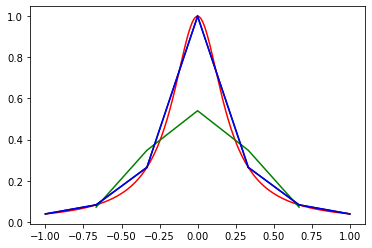

In [6]:
e=7
max_dif=[]
x=np.linspace(-1,1,e)
"wzorzec"
x_wz=np.linspace(-1,1,1000)
fx=lambda x : 1/(25*x*x+1)
y=fx(x_wz)
plt.plot(x_wz,y,'r',label='wzorzec')

"interpolacja barycentryczna"
w=main.bar_czeb_weights(e)
xn=main.chebyshev_nodes(e)
Yn=main.barycentric_inte(xn,fx(xn),w,x)
plt.plot(x,Yn,'g',label='interpolacja barycentryczna')

"first splajn"
a,b=main.first_spline(x,fx(x))
f = [[b[i],a[i]] for i in range(len(a))]

for i in range(len(x)-1):
    x_new = np.linspace(x[i], x[i+1],1000)
    plt.plot(x_new, PolyCoefficients(x_new, f[i]),'k',label='first splajn')
"splrep"
sp=splrep(x,fx(x))
ys=splev(x,sp)
plt.plot(x,ys,'b',label='splrep')

***Zadanie 3.***  
Korzystając z funkcji z pakietu [scipy.interpolate.splprep](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.splprep.html#scipy.interpolate.splprep), funkcji zaimplementowanej w Zadaniu 1 oraz interpolacji barycentrycznej z węzłami równoodległymi (korzystając z kodu z poprzedniego zadania) dokonaj interpolacji funkcji: 
    
### $ f(x) = cos(x)x^4$

W przedziale \[-1, 1\]

Dokonaj porównania wyników otrzymanych:  
Wykorzystując funkcję z ubiegłego tygodnia, ocenić jakość interpolacji funkcji spline pierwszego stopnia z wartościami danej funkcji.


c:\Users\domin\OneDrive\Pulpit\Metody_Numeryczne\laboratorium-5-ADstr\main.py:131: RuntimeWarning: divide by zero encountered in true_divide
  L = wi/(x-xi)
c:\Users\domin\OneDrive\Pulpit\Metody_Numeryczne\laboratorium-5-ADstr\main.py:133: RuntimeWarning: invalid value encountered in double_scalars
  Y.append(yi @ L / sum(L))


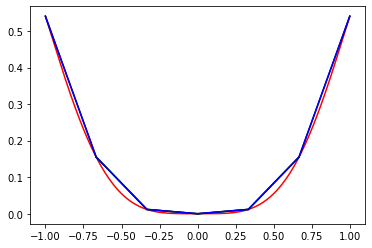

In [8]:
e=7
max_dif=[]
x=np.linspace(-1,1,e)
"wzorzec"
x_wz=np.linspace(-1,1,1000)
fx=lambda x : np.cos(x)*x**4
y=fx(x_wz)
plt.plot(x_wz,y,'r',label='wzorzec')

"interpolacja barycentryczna"
w=main.bar_czeb_weights(e)
xn=main.chebyshev_nodes(e)
Yn=main.barycentric_inte(xn,fx(xn),w,x)
plt.plot(x,Yn,'g',label='interpolacja barycentryczna')


"first splajn"
a,b=main.first_spline(x,fx(x))
f = [[b[i],a[i]] for i in range(len(a))]

for i in range(len(x)-1):
    x_new = np.linspace(x[i], x[i+1],1000)
    plt.plot(x_new, PolyCoefficients(x_new, f[i]),'k',label='first splajn')
"splrep"
sp=splrep(x,fx(x))
ys=splev(x,sp)
plt.plot(x,ys,'b',label='splrep')


***Zadanie 4.***  
Zaimplementuj funkcję interpolującą sklejaną trzeciego rzędu (splajn kubiczny). Jako dane wejściowe dane są dwa wektory: argumentów oraz wartości funkcji. Funkcja ma zwracać współczynniki funkcji wielomianowych w poszczególnych przedziałach.

***Podpowiedź***

https://medium.com/eatpredlove/natural-cubic-splines-implementation-with-python-edf68feb57aa



***Zadania 5.***  
Korzystając z funkcji z pakietu [scipy.interpolate.splprep](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.splprep.html#scipy.interpolate.splprep), funkcji zaimplementowanej w Zadaniu 4: 
    
### $ f(x) = \frac{1}{25x^2+1}$

W przedziale \[-1, 1\]

Dokonaj porównania wyników otrzymanych:  
Wykorzystując funkcję z ubiegłego tygodnia, ocenić jakość interpolacji funkcji spline pierwszego stopnia z wartościami danej funkcji.


***Zadanie 6.***  
Korzystając z funkcji z pakietu [scipy.interpolate.splprep](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.splprep.html#scipy.interpolate.splprep), funkcji zaimplementowanej w Zadaniu 4: 
    
### $ f(x) = cos(x)x^4$

W przedziale \[-1, 1\]

Dokonaj porównania wyników otrzymanych:  
Wykorzystując funkcję z ubiegłego tygodnia, ocenić jakość interpolacji funkcji spline pierwszego stopnia z wartościami danej funkcji.


***Zadanie 7.***  
Dla funkcji:
### $f(x) = |sin(5x)|^3$

Porównać działanie funkcji zaimplementowanych w Zadaniu 1 oraz 4 oraz przedstawić wyniki na odpowiednich wykresach.